In [13]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
from tqdm import tqdm

from joblib import Parallel, delayed

import pickle

import schwingerModel as sim

from schwingerModel.interpolator import MesonOp, mesonMultiplet, makeState, parityTransform


In [122]:
def triplet(op):                       # the pi+-type member: connected-only, like the old path
    return mesonMultiplet(op, 1)[+1]

def singlet(op):                       
    return mesonMultiplet(op, 0)[0]

In [5]:
path = "./configs/400kSteps.hdf5"
meta = sim.distillation.readDistillMeta(path)

In [111]:
mom0Basis = [triplet(MesonOp("g5",DNum=0,momk=0)),triplet(MesonOp("g5",DNum=2,momk=0))]
mom1Basis = [triplet(MesonOp("g5",DNum=0,momk=1)),triplet(MesonOp("g5",DNum=2,momk=1))]
mom2Basis = [triplet(MesonOp("g5",DNum=0,momk=2)),triplet(MesonOp("g5",DNum=2,momk=2))]
mom3Basis = [triplet(MesonOp("g5",DNum=0,momk=3)),triplet(MesonOp("g5",DNum=2,momk=3))]

momentumBases = [mom0Basis,mom1Basis,mom2Basis,mom3Basis]

In [112]:
gevpTi = 2

massOuts = []

for basis in momentumBases:
    data_p = sim.GEVP.measureEnsemble(path,(meta.configIndices)[::50],basis)
    data_m = sim.GEVP.measureEnsemble(path,(meta.configIndices)[::50],[parityTransform(op) for op in basis])

    data = {"conn": 0.5*(data_p["conn"] + data_m["conn"]), "disc": data_p["disc"]}  

    mass = sim.GEVP.bootstrapEnsemble(data,reduce=sim.GEVP.massReduce(ti=gevpTi, shift=0,
                                  fitT=[2,10], withAmp=True))

    massOuts.append(mass)

Measuring configs:   0%|          | 0/1600 [00:00<?, ?it/s]

Measuring configs:   0%|          | 0/1600 [00:00<?, ?it/s]

Bootstrap reduce:   0%|          | 0/10000 [00:00<?, ?it/s]

Measuring configs:   0%|          | 0/1600 [00:00<?, ?it/s]

Measuring configs:   0%|          | 0/1600 [00:00<?, ?it/s]

...

Measuring configs:   0%|          | 0/1600 [00:00<?, ?it/s]

Bootstrap reduce:   0%|          | 0/10000 [00:00<?, ?it/s]

Measuring configs:   0%|          | 0/1600 [00:00<?, ?it/s]

Measuring configs:   0%|          | 0/1600 [00:00<?, ?it/s]

Bootstrap reduce:   0%|          | 0/10000 [00:00<?, ?it/s]

In [124]:
masses = np.array([m[0][0][0] for m in massOuts])
massesErr = np.mean(np.array([m[1][0][0] for m in massOuts]).T, axis=0)

ks = np.array([0,1,2,3])

Text(0.5, 1.0, '$\\pi$ Disp. Rel: $N_t$:32, $N_x$:16, $\\beta$:10.0, $m_q$:0.2')

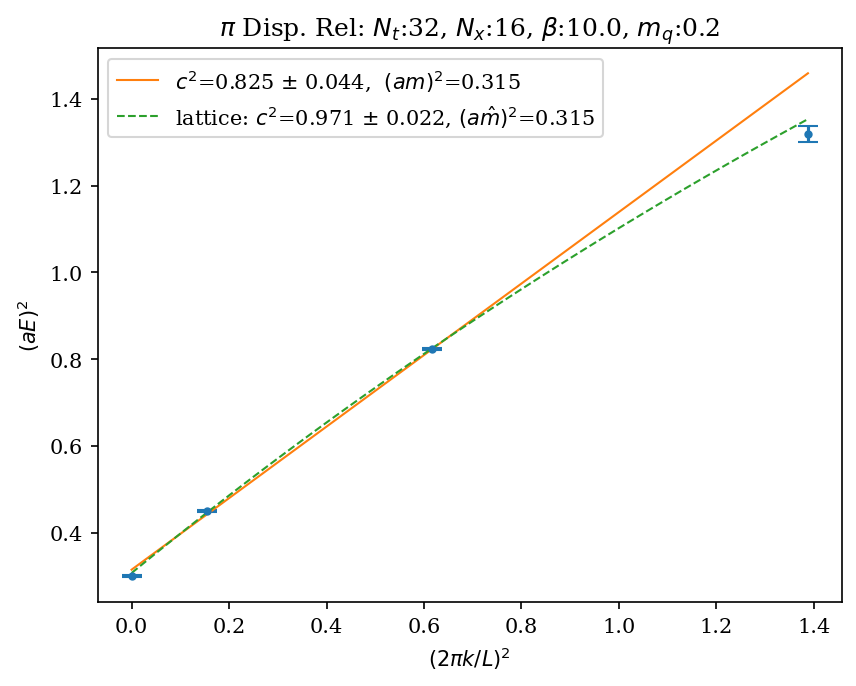

In [126]:
fineKs = np.linspace(0,3,100)
pf = ((2 * np.pi*fineKs)/(meta.dimx))**2

ps = (2 * np.pi*ks)/(meta.dimx)

sig = 2*masses*massesErr

coeff, cov = np.polyfit(ps**2,masses**2,deg=1,cov=True,w=1/sig)
c2 , m2 = coeff
dc2 = np.sqrt(cov[0,0])

sigLat = 2*np.sinh(masses)*massesErr      # d/dE [4 sinh^2(E/2)] = 2 sinh(E)

coeffLat, covLat = np.polyfit(4*np.sin(ps/2)**2,4*np.sinh(masses/2)**2,deg=1,cov=True,w=1/sig)
c2Lat , m2Lat = coeffLat
dc2Lat = np.sqrt(covLat[0,0])

pfLin = np.sqrt(pf)                                  # pf is the (ap)^2 grid -> ap values

Ehat2 = m2Lat + c2Lat * 4*np.sin(pfLin/2)**2         # lattice-form prediction
Elat  = 2*np.arcsinh(np.sqrt(Ehat2)/2)               # invert 4sinh^2(aE/2) = Ehat2

plt.figure(dpi=150)

plt.errorbar(x=ps**2,y=masses**2,yerr=2*masses*massesErr,fmt=".",capsize=5)
plt.plot(pf, m2 + c2*pf, lw=1,
         label=rf"$c^2$={c2:.3f} $\pm$ {dc2:.3f},  $(am)^2$={m2:.3f}")

plt.plot(pf, Elat**2, lw=1, ls="--",
         label=rf"lattice: $c^2$={c2Lat:.3f} $\pm$ {dc2Lat:.3f}, $(a\hat m)^2$={m2Lat:.3f}")

plt.xlabel(r"$(2 \pi k/L)^2$")
plt.ylabel("$(aE)^2$")
plt.legend()

plt.title(rf"$\pi$ Disp. Rel: $N_t$:{meta.dimt}, $N_x$:{meta.dimx}, $\beta$:{meta.beta}, $m_q$:{meta.fMass}")